In [1]:
import pandas as pd
import numpy as np

day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

day.head()
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
day.drop(columns=['instant'], inplace=True)
hour.drop(columns=['instant'], inplace=True)

day.head()
hour.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
# STEP 2: Separate target and features

target = 'cnt'

# DAY dataset
X_day = day.drop(columns=[target])
y_day = day[target]

# HOUR dataset
X_hour = hour.drop(columns=[target])
y_hour = hour[target]


print("DAY features:", X_day.columns)
print("DAY target:", y_day.name)

print("HOUR features:", X_hour.columns)
print("HOUR target:", y_hour.name)


print('cnt' in X_day.columns)   # False
print('cnt' in X_hour.columns) # False


DAY features: Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')
DAY target: cnt
HOUR features: Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered'],
      dtype='object')
HOUR target: cnt
False
False


In [5]:
day.isnull().sum()
hour.isnull().sum()


dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in ['temp','atemp','hum','windspeed','cnt']:
    day = remove_outliers(day, col)

day.head()   # to display result


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


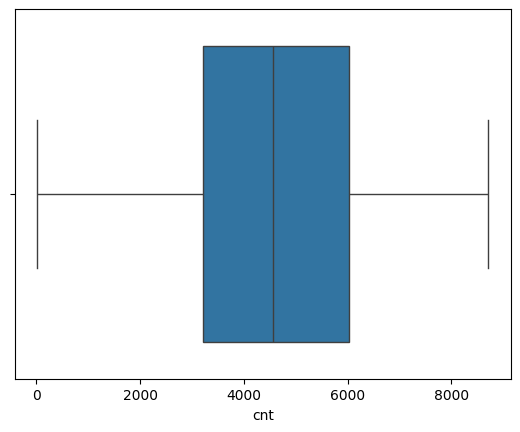

0      6.893656
1      6.687109
2      7.207860
3      7.354362
4      7.378384
         ...   
726    7.656810
727    8.037866
728    7.201916
729    7.493874
730    7.912057
Name: cnt_log, Length: 717, dtype: float64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x=day['cnt'])
plt.show()

# Log transform instead of outlier removal

day['cnt_log'] = np.log1p(day['cnt'])
print(day['cnt_log'])

In [8]:
# Apply same logic to hour dataset
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in num_cols:
    hour = remove_outliers(hour, col)

hour.head()

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x=day['cnt'])
plt.show()

# Log transform instead of outlier removal

hour['cnt_log'] = np.log1p(hour['cnt'])


NameError: name 'num_cols' is not defined

In [ ]:
categorical_cols = ['season','weathersit','mnth','weekday']

day = pd.get_dummies(day, columns=categorical_cols, drop_first=True)
hour = pd.get_dummies(hour, columns=categorical_cols, drop_first=True)

day.columns
hour.columns


In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['temp','atemp','hum','windspeed']

print("Before scaling (DAY):")
print(day[scale_cols].describe())
print("Before scaling (Hour):")
print(hour[scale_cols].describe())
scaler = StandardScaler()
day[scale_cols] = scaler.fit_transform(day[scale_cols])
hour[scale_cols] = scaler.fit_transform(hour[scale_cols])

# Apply scaling (already done)

print("\nAfter scaling (DAY):")
print("Before scaling (Hour):")
print(day[scale_cols].describe())
print(hour[scale_cols].describe())


In [ ]:
import matplotlib.pyplot as plt

day[scale_cols].hist(bins=20, figsize=(10,6))
plt.suptitle("Scaled Feature Distributions (DAY)")
plt.show()


In [ ]:
# Date-based Features
day['dteday'] = pd.to_datetime(day['dteday'])
hour['dteday'] = pd.to_datetime(hour['dteday'])

day['year'] = day['dteday'].dt.year
day['month'] = day['dteday'].dt.month
day['day'] = day['dteday'].dt.day

day[['dteday','year','month','day']].head()


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='month', y='cnt', data=day)
plt.title("Average Bike Rentals by Month")
plt.show()


ValueError: Could not interpret value `month` for `x`. An entry with this name does not appear in `data`.

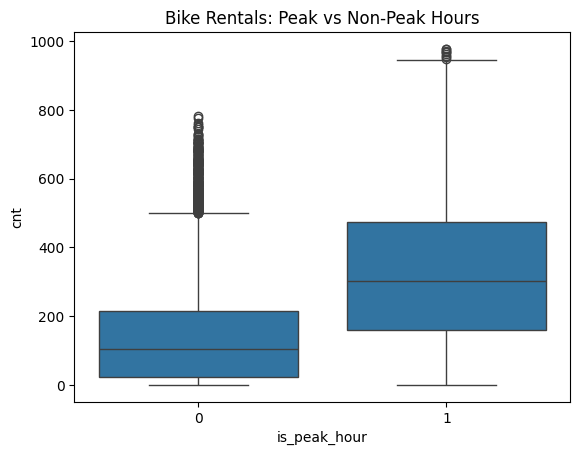

In [13]:
# Time-based Feature (ONLY hour.csv)
hour['is_peak_hour'] = hour['hr'].apply(
    lambda x: 1 if x in [7,8,9,17,18,19] else 0
)

hour[['hr','is_peak_hour']].head(10)

sns.boxplot(x='is_peak_hour', y='cnt', data=hour)
plt.title("Bike Rentals: Peak vs Non-Peak Hours")
plt.show()


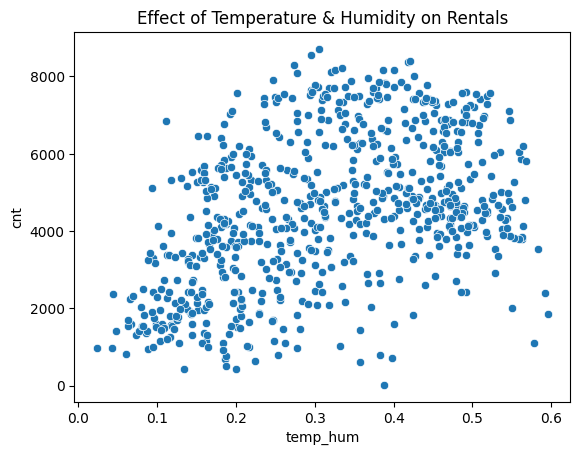

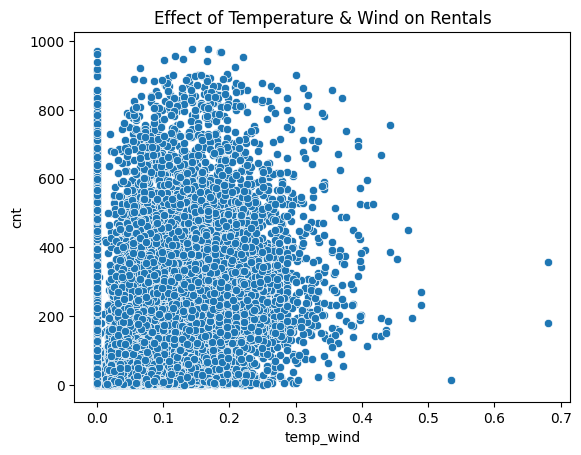

In [14]:
# Interaction Features

day['temp_hum'] = day['temp'] * day['hum']
hour['temp_wind'] = hour['temp'] * hour['windspeed']

day[['temp','hum','temp_hum']].head()
hour[['temp','windspeed','temp_wind']].head()

sns.scatterplot(x='temp_hum', y='cnt', data=day)
plt.title("Effect of Temperature & Humidity on Rentals")
plt.show()

sns.scatterplot(x='temp_wind', y='cnt', data=hour)
plt.title("Effect of Temperature & Wind on Rentals")
plt.show()


In [15]:
if 'atemp' in day.columns:
    print(day[['temp','atemp']].corr())
else:
    print("atemp already removed due to multicollinearity")


           temp     atemp
temp   1.000000  0.991738
atemp  0.991738  1.000000


In [16]:
# Feature Selection
corr = day.corr()['cnt'].abs().sort_values(ascending=False)
corr

important_features = corr[corr > 0.2].index
important_features = important_features.drop('cnt')


ValueError: could not convert string to float: '2011-01-01'

In [17]:
import matplotlib.pyplot as plt

corr.drop('cnt').plot(kind='bar', figsize=(10,4))
plt.title("Feature Correlation with Target (cnt)")
plt.ylabel("Absolute Correlation")
plt.show()


NameError: name 'corr' is not defined

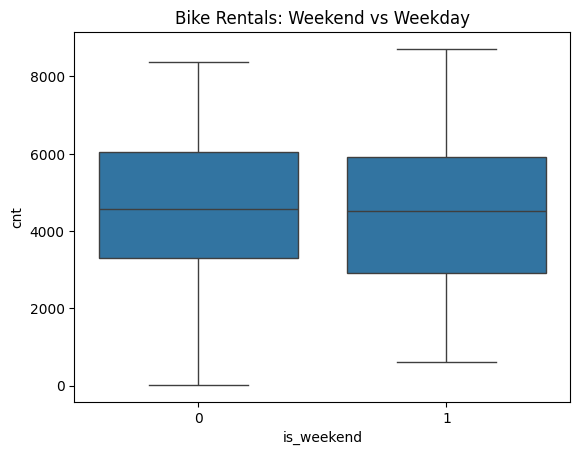

In [9]:
day['is_weekend'] = day['weekday'].apply(lambda x: 1 if x in [0,6] else 0)
hour['is_weekend'] = hour['weekday'].apply(lambda x: 1 if x in [0,6] else 0)
day[['weekday','is_weekend']].head()
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='is_weekend', y='cnt', data=day)
plt.title("Bike Rentals: Weekend vs Weekday")
plt.show()


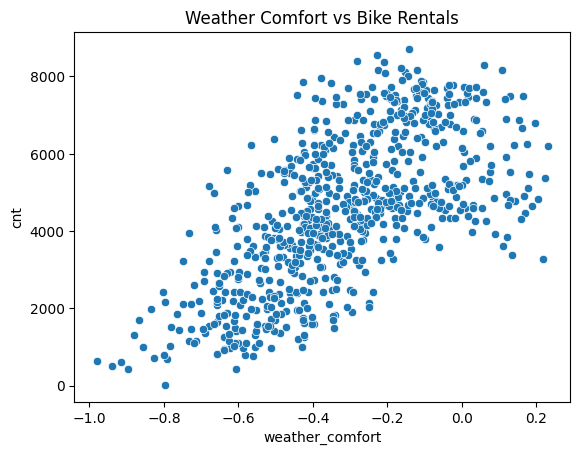

In [10]:
day['weather_comfort'] = day['temp'] - (day['hum'] + day['windspeed'])
hour['weather_comfort'] = hour['temp'] - (hour['hum'] + hour['windspeed'])
day[['temp','hum','windspeed','weather_comfort']].head()
sns.scatterplot(x='weather_comfort', y='cnt', data=day)
plt.title("Weather Comfort vs Bike Rentals")
plt.show()


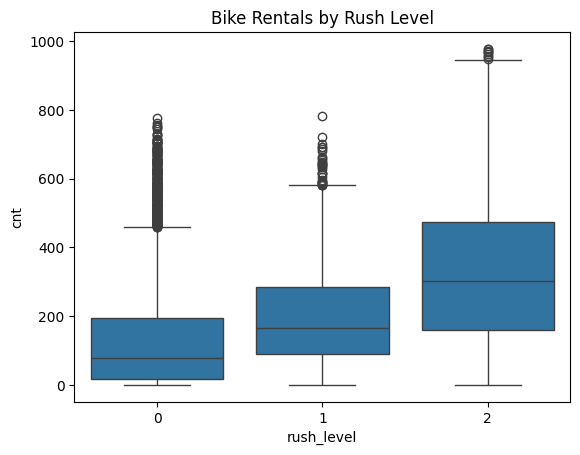

In [11]:
def rush_level(hr):
    if hr in [7,8,9,17,18,19]:
        return 2
    elif hr in [6,10,16,20]:
        return 1
    else:
        return 0

hour['rush_level'] = hour['hr'].apply(rush_level)
hour[['hr','rush_level']].head(10)
sns.boxplot(x='rush_level', y='cnt', data=hour)
plt.title("Bike Rentals by Rush Level")
plt.show()


In [18]:
season_map = {1:0.8, 2:1.1, 3:1.2, 4:0.9}
day['season_demand'] = day['season'].map(season_map)
hour['season_demand'] = hour['season'].map(season_map)
day[['season','season_demand']].head()


,season,season_demand
0,1,0.8
1,1,0.8
2,1,0.8
3,1,0.8
4,1,0.8


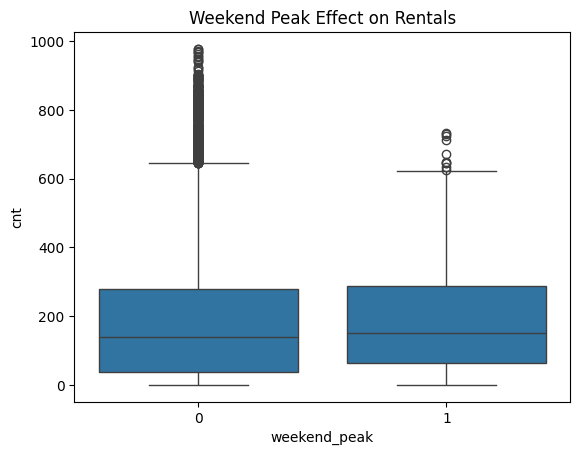

In [19]:
hour['weekend_peak'] = hour['is_weekend'] * hour['is_peak_hour']
hour[['is_weekend','is_peak_hour','weekend_peak']].head()
sns.boxplot(x='weekend_peak', y='cnt', data=hour)
plt.title("Weekend Peak Effect on Rentals")
plt.show()


In [20]:
# Demand Ratio Feature (casual_ratio, registered_ratio)
day['casual_ratio'] = day['casual'] / (day['cnt'] + 1)
day['registered_ratio'] = day['registered'] / (day['cnt'] + 1)

hour['casual_ratio'] = hour['casual'] / (hour['cnt'] + 1)
hour['registered_ratio'] = hour['registered'] / (hour['cnt'] + 1)


In [21]:
# Rolling Mean Demand (Trend Feature)
day['cnt_rolling_3'] = day['cnt'].rolling(window=3).mean()
day['cnt_rolling_7'] = day['cnt'].rolling(window=7).mean()
day[['cnt','cnt_rolling_3','cnt_rolling_7']].head(10)


,cnt,cnt_rolling_3,cnt_rolling_7
0,985,NaN,NaN
1,801,NaN,NaN
2,1349,1045.000000,NaN
3,1562,1237.333333,NaN
4,1600,1503.666667,NaN
5,1606,1589.333333,NaN
6,1510,1572.000000,1344.714286
7,959,1358.333333,1341.000000
8,822,1097.000000,1344.000000
9,1321,1034.000000,1340.000000


In [22]:
# Lag Feature (Previous Day Demand)
day['cnt_lag_1'] = day['cnt'].shift(1)
day['cnt_lag_7'] = day['cnt'].shift(7)
day[['cnt','cnt_lag_1','cnt_lag_7']].head(10)


,cnt,cnt_lag_1,cnt_lag_7
0,985,NaN,NaN
1,801,985.0,NaN
2,1349,801.0,NaN
3,1562,1349.0,NaN
4,1600,1562.0,NaN
5,1606,1600.0,NaN
6,1510,1606.0,NaN
7,959,1510.0,985.0
8,822,959.0,801.0
9,1321,822.0,1349.0


In [23]:
# Weather Severity Flag (bad_weather)
day['bad_weather'] = ((day['hum'] > 0.8) | (day['windspeed'] > 0.6)).astype(int)
hour['bad_weather'] = ((hour['hum'] > 0.8) | (hour['windspeed'] > 0.6)).astype(int)


In [24]:
# Temperature Zone Feature (temp_zone)
def temp_zone(t):
    if t < 0.3:
        return 0   # cold
    elif t < 0.6:
        return 1   # moderate
    else:
        return 2   # hot

day['temp_zone'] = day['temp'].apply(temp_zone)
hour['temp_zone'] = hour['temp'].apply(temp_zone)


In [3]:
# linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = day.drop(columns=['cnt'])
y = day['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred, squared=False))


ValueError: could not convert string to float: '2012-11-13'

In [2]:
Ridge Regression (Handles Multicollinearity)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))


NameError: name 'X_train' is not defined

In [ ]:
# Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

pred = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))


In [ ]:
# Random Forest Regressor (BEST classical model)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))


In [ ]:
# Gradient Boosting / XGBoost (TOP PERFORMANCE)
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gbr.fit(X_train, y_train)
pred = gbr.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))


In [ ]:
# Optional (Advanced): XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
